In [2]:
from pathlib import Path

import pandas as pd

from src.data.loader import load_meld
from src.analysis.trajectories import (
    build_valid_transitions,
    transition_counts,
    transition_probabilities,
    calculate_persistence,
    calculate_dialogue_shifts,
    summarize_trajectories,
)

DATA_DIR = Path("../data/raw/meld")
OUTPUT_DIR = Path("../outputs")

dataset = load_meld(DATA_DIR)

In [3]:
from src.analysis.trajectories import build_valid_transitions
from src.analysis.speaker_dynamics import (
    classify_speaker_transitions,
    calculate_speaker_transition_summary,
    speaker_transition_counts,
    speaker_transition_probabilities,
    speaker_persistence,
)

# Build valid consecutive transitions
test_transitions = build_valid_transitions(dataset.test)

# Add same-speaker / cross-speaker classification
test_transitions = classify_speaker_transitions(test_transitions)

print("Test transitions:", len(test_transitions))
print()
print(test_transitions["speaker_transition"].value_counts())

Test transitions: 2328

speaker_transition
cross_speaker    1765
same_speaker      563
Name: count, dtype: int64


In [4]:
summary = calculate_speaker_transition_summary(test_transitions)

summary

,speaker_transition,transitions,emotion_shifts,shift_rate,persistence_rate
0,same_speaker,563,238,0.422735,0.577265
1,cross_speaker,1765,1114,0.631161,0.368839


In [5]:
counts = speaker_transition_counts(test_transitions)

print("SAME SPEAKER")
display(counts["same_speaker"])

print("\nCROSS SPEAKER")
display(counts["cross_speaker"])

SAME SPEAKER


emotion_to,anger,disgust,fear,joy,neutral,sadness,surprise
emotion_from,,,,,,,
anger,72,3,2,2,24,8,3
disgust,7,4,0,0,2,0,2
fear,0,0,3,1,9,1,0
joy,6,1,2,42,28,2,4
neutral,20,1,11,22,168,12,10
sadness,4,0,2,6,18,26,1
surprise,10,0,0,4,5,5,10



CROSS SPEAKER


emotion_to,anger,disgust,fear,joy,neutral,sadness,surprise
emotion_from,,,,,,,
anger,42,9,2,15,86,17,28
disgust,7,4,0,7,14,3,9
fear,3,2,0,2,12,3,9
joy,17,7,1,81,118,9,31
neutral,75,21,17,130,471,59,108
sadness,12,3,2,14,54,29,14
surprise,32,8,2,32,107,13,24


In [6]:
probabilities = speaker_transition_probabilities(test_transitions)

print("SAME SPEAKER")
display(probabilities["same_speaker"].round(3))

print("\nCROSS SPEAKER")
display(probabilities["cross_speaker"].round(3))

SAME SPEAKER


emotion_to,anger,disgust,fear,joy,neutral,sadness,surprise
emotion_from,,,,,,,
anger,0.632,0.026,0.018,0.018,0.211,0.070,0.026
disgust,0.467,0.267,0.000,0.000,0.133,0.000,0.133
fear,0.000,0.000,0.214,0.071,0.643,0.071,0.000
joy,0.071,0.012,0.024,0.494,0.329,0.024,0.047
neutral,0.082,0.004,0.045,0.090,0.689,0.049,0.041
sadness,0.070,0.000,0.035,0.105,0.316,0.456,0.018
surprise,0.294,0.000,0.000,0.118,0.147,0.147,0.294



CROSS SPEAKER


emotion_to,anger,disgust,fear,joy,neutral,sadness,surprise
emotion_from,,,,,,,
anger,0.211,0.045,0.010,0.075,0.432,0.085,0.141
disgust,0.159,0.091,0.000,0.159,0.318,0.068,0.205
fear,0.097,0.065,0.000,0.065,0.387,0.097,0.290
joy,0.064,0.027,0.004,0.307,0.447,0.034,0.117
neutral,0.085,0.024,0.019,0.148,0.535,0.067,0.123
sadness,0.094,0.023,0.016,0.109,0.422,0.227,0.109
surprise,0.147,0.037,0.009,0.147,0.491,0.060,0.110


In [7]:
persistence = speaker_persistence(test_transitions)

persistence

,speaker_transition,transitions,persistent_transitions,persistence_rate
0,same_speaker,563,325,0.577265
1,cross_speaker,1765,651,0.368839


In [8]:
import pandas as pd

transitions = test_transitions.copy()

# Look at the next transition within the same dialogue
transitions["next_dialogue_id"] = transitions["dialogue_id"].shift(-1)
transitions["next_utterance_id"] = transitions["utterance_id"].shift(-1)
transitions["next_emotion_from"] = transitions["emotion_to"].shift(-1)

# The following transition must be the immediately consecutive transition
valid_following = (
    (transitions["next_dialogue_id"] == transitions["dialogue_id"])
    & (transitions["next_utterance_id"] == transitions["utterance_id"] + 1)
)

# Current transition is an emotion change
is_shift = transitions["emotion_from"] != transitions["emotion_to"]

# New emotion continues into the next utterance
is_sustained = transitions["emotion_to"] == transitions["next_emotion_from"]

transitions["turning_point"] = (
    valid_following
    & is_shift
    & is_sustained
)

turning_points = transitions[transitions["turning_point"]].copy()

print("Turning points:", len(turning_points))
print("Total valid transitions:", len(transitions))
print(
    "Turning-point rate among valid transitions:",
    turning_points.shape[0] / len(transitions)
)

Turning points: 371
Total valid transitions: 2328
Turning-point rate among valid transitions: 0.15936426116838487


In [9]:
turning_points[
    [
        "dialogue_id",
        "utterance_id",
        "speaker_from",
        "speaker_to",
        "emotion_from",
        "emotion_to",
        "speaker_transition",
    ]
].head(20)

,dialogue_id,utterance_id,speaker_from,speaker_to,emotion_from,emotion_to,speaker_transition
2,1,0,Joey,Joey,neutral,joy,same_speaker
12,2,3,Ross,Rachel,surprise,anger,cross_speaker
15,2,6,Ross,Ross,anger,joy,same_speaker
17,2,8,Ross,Ross,joy,neutral,same_speaker
20,3,1,Ross,Steve,fear,neutral,cross_speaker
26,4,1,Monica,Phoebe,neutral,surprise,cross_speaker
33,5,0,Chandler,Chandler,anger,neutral,same_speaker
49,7,6,Monica,Ross,surprise,neutral,cross_speaker
54,8,3,Ross,Chandler,surprise,neutral,cross_speaker
59,9,2,Fireman #1,Phoebe,sadness,surprise,cross_speaker


In [10]:
turning_point_summary = (
    turning_points
    .groupby(["emotion_from", "emotion_to"])
    .size()
    .reset_index(name="turning_points")
    .sort_values("turning_points", ascending=False)
)

turning_point_summary

,emotion_from,emotion_to,turning_points
13,joy,neutral,61
2,anger,neutral,47
19,neutral,joy,44
30,surprise,neutral,43
25,sadness,neutral,32
16,neutral,anger,16
27,surprise,anger,15
21,neutral,surprise,12
3,anger,sadness,11
20,neutral,sadness,11


In [11]:
turning_points["speaker_transition"].value_counts()

speaker_transition
cross_speaker    268
same_speaker     103
Name: count, dtype: int64

In [12]:
from pathlib import Path

output_dir = Path("../outputs/tables")
output_dir.mkdir(parents=True, exist_ok=True)

summary.to_csv(
    output_dir / "week8_speaker_transition_summary.csv",
    index=False
)

probabilities["same_speaker"].to_csv(
    output_dir / "week8_same_speaker_transition_probabilities.csv"
)

probabilities["cross_speaker"].to_csv(
    output_dir / "week8_cross_speaker_transition_probabilities.csv"
)

turning_point_summary.to_csv(
    output_dir / "week8_turning_point_summary.csv",
    index=False
)

print("Week 8 tables saved.")

Week 8 tables saved.


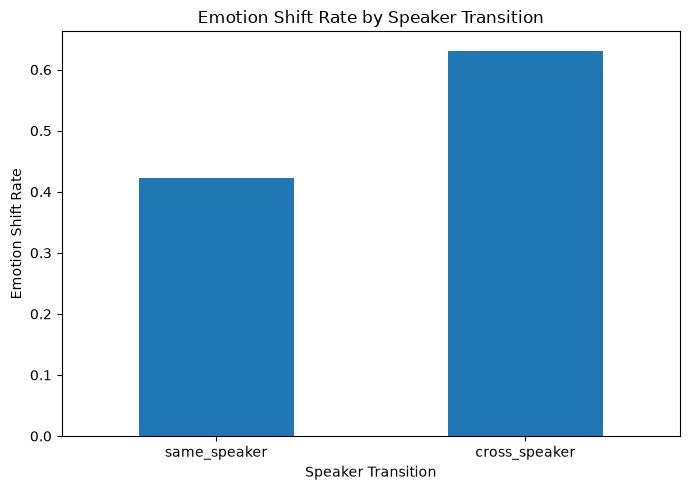

In [13]:
import matplotlib.pyplot as plt

plot_df = summary.set_index("speaker_transition")

plt.figure(figsize=(7, 5))
plot_df["shift_rate"].plot(kind="bar")
plt.ylabel("Emotion Shift Rate")
plt.xlabel("Speaker Transition")
plt.title("Emotion Shift Rate by Speaker Transition")
plt.xticks(rotation=0)
plt.tight_layout()

figure_dir = Path("../outputs/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figure_dir / "week8_speaker_shift_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

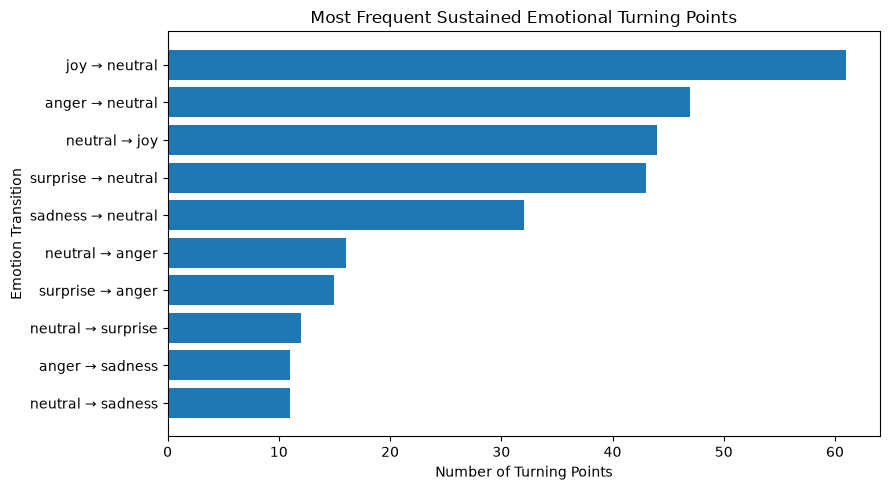

In [14]:
top_turning_points = turning_point_summary.head(10).copy()

top_turning_points["transition"] = (
    top_turning_points["emotion_from"]
    + " → "
    + top_turning_points["emotion_to"]
)

plt.figure(figsize=(9, 5))
plt.barh(
    top_turning_points["transition"][::-1],
    top_turning_points["turning_points"][::-1]
)
plt.xlabel("Number of Turning Points")
plt.ylabel("Emotion Transition")
plt.title("Most Frequent Sustained Emotional Turning Points")
plt.tight_layout()

plt.savefig(
    figure_dir / "week8_top_turning_points.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()